
# Optimisation results analysis
We will conduct a turbine-level analysis to understand how each of the optimisers work.

The case study used is Horns Rev 1.

In [87]:
import numpy as np
import seaborn
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import json
import sys
%matplotlib widget
import pandas as pd

plt.style.use('default')

BASELINE_HR1_POWER = 63.492160278290314  # megawatts of unyawed HR1
KEYS = ["best_yaw", "per_case_power_MW", "wind_dir_deg", "wind_speed", "weights"]

### Load the necessary .npz files


In [133]:
# Serial-Refine
sr_data = np.load(rf".\yaw_serial_hr1\20260309_172931\arrays.npz")

# SLSQP
slsqp_data = np.load(rf".\yaw_slsqp_hr1\20260309_173450\arrays.npz")

In [134]:
sr_data = {key: sr_data[key] for key in KEYS}
slsqp_data = {key: slsqp_data[key] for key in KEYS}

# Convert degrees to radians
sr_data['best_yaw'] = np.rad2deg(sr_data['best_yaw'])
slsqp_data['best_yaw'] = np.rad2deg(slsqp_data['best_yaw'])

sr_yaw = sr_data['best_yaw']
slsqp_yaw = slsqp_data['best_yaw']
sr_opt_power = sr_data['per_case_power_MW'][0]
slsqp_opt_power = slsqp_data['per_case_power_MW'][0]

## We can use FLORIS to plot wind turbine yaw angles

In [135]:
sr_yaw

array([[25.    , 25.    , 25.    , 25.    , 25.    , 25.    , 25.    ,
        25.    , 20.3125, 20.3125, 20.3125, 20.3125, 20.3125, 20.3125,
        20.3125, 20.3125, 20.3125, 20.3125, 20.3125, 20.3125, 20.3125,
        20.3125, 20.3125, 20.3125, 18.75  , 18.75  , 18.75  , 18.75  ,
        18.75  , 18.75  , 18.75  , 18.75  , 18.75  , 18.75  , 18.75  ,
        18.75  , 18.75  , 18.75  , 18.75  , 18.75  , 15.625 , 15.625 ,
        15.625 , 15.625 , 15.625 , 15.625 , 15.625 , 15.625 , 14.0625,
        14.0625, 14.0625, 14.0625, 14.0625, 14.0625, 14.0625, 12.5   ,
         9.375 ,  9.375 ,  9.375 ,  9.375 ,  9.375 ,  9.375 ,  9.375 ,
         9.375 ,  6.25  ,  6.25  ,  6.25  ,  6.25  ,  6.25  ,  6.25  ,
         6.25  ,  6.25  ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ]])

In [136]:
slsqp_yaw

array([[1.42548385e+01, 2.34751794e+01, 2.11103585e+01, 2.39531962e+01,
        2.31200797e+01, 2.50000133e+01, 2.50000001e+01, 2.50000001e+01,
        2.20165276e+01, 1.99470046e+01, 1.99444413e+01, 1.99601744e+01,
        2.00571731e+01, 2.00357507e+01, 2.00131271e+01, 1.99666712e+01,
        1.84750007e+01, 1.81360487e+01, 1.81422234e+01, 1.80559513e+01,
        1.80699810e+01, 1.80825236e+01, 1.80513208e+01, 1.80064959e+01,
        1.71244416e+01, 1.67361738e+01, 1.67460525e+01, 1.67386700e+01,
        1.67864815e+01, 1.66131539e+01, 1.66726690e+01, 1.66430618e+01,
        1.59679578e+01, 1.54192659e+01, 1.55250701e+01, 1.54876254e+01,
        1.54769479e+01, 1.53857204e+01, 1.54405124e+01, 1.54330944e+01,
        1.48259655e+01, 1.42939273e+01, 1.43218075e+01, 1.41392517e+01,
        1.42406767e+01, 1.41648969e+01, 1.41455144e+01, 1.41691188e+01,
        1.35556425e+01, 1.31387652e+01, 1.25454660e+01, 1.28672462e+01,
        1.29784277e+01, 1.29157704e+01, 1.24827843e+01, 1.245715

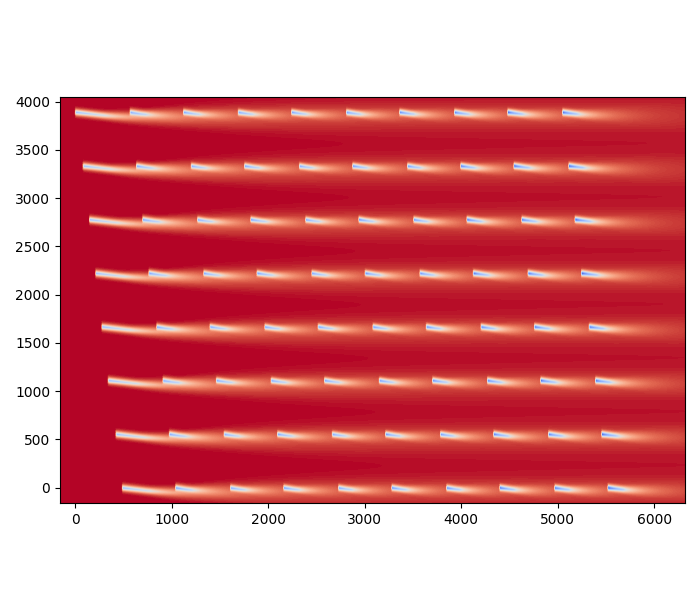

In [140]:
import floris.flow_visualization as flowviz
import floris.layout_visualization as layout_viz
from floris import FlorisModel
import yaml

def loader_with_include(path):
    """Custom YAML loader to support the !include tag."""
    class IncludeLoader(yaml.SafeLoader):
        def __init__(self, stream):
            self._root = os.path.split(stream.name)[0]
            super(IncludeLoader, self).__init__(stream)

    def construct_include(loader, node):
        filename = os.path.join(loader._root, loader.construct_scalar(node))
        with open(filename, 'r') as f:
            return yaml.load(f, IncludeLoader)

    yaml.add_constructor('!include', construct_include, IncludeLoader)
    return IncludeLoader

hr1_yaml = rf"..\data\horn\gch.yaml"
with open(hr1_yaml, 'r') as f:
    hr1_params = yaml.load(f, loader_with_include(hr1_yaml))

lx = hr1_params['farm']['layout_x']
ly = hr1_params['farm']['layout_y']

plt.style.use('default')

def plot_yaw_angles(yaw_angles: np.ndarray):
    fmodel = FlorisModel(hr1_yaml)
    fmodel.set(yaw_angles=yaw_angles)
    fmodel.run()

    fig, ax = plt.subplots(figsize=(7, 6))

    horizontal_plane = fmodel.calculate_horizontal_plane(height=90.0, x_resolution=400, y_resolution=400)
    flow = flowviz.visualize_cut_plane(horizontal_plane,ax=ax, levels=150)

    plt.tight_layout()
    plt.show()

plot_yaw_angles(sr_yaw)

In [ ]:
plot_yaw_angles(slsqp_yaw)

## JSONL data

Let's have a look at 3 turbines and see how their yaw angles change individually. We can separate the rows of turbines into 3

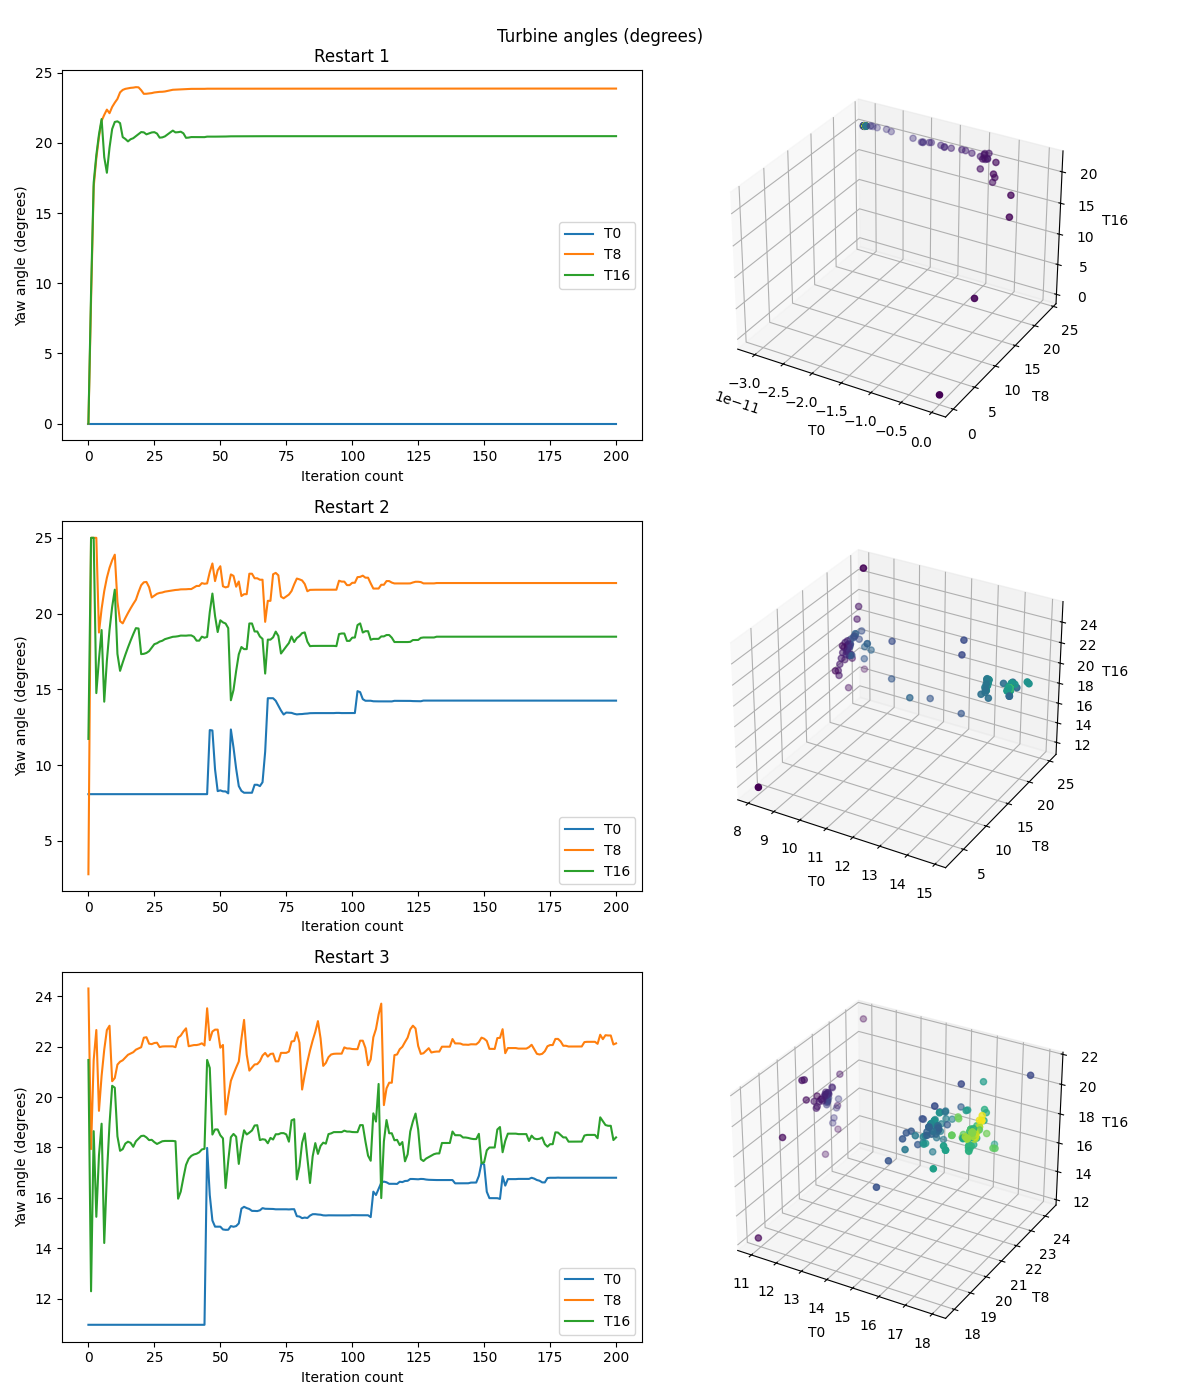

In [142]:
slsqp_log = []
with open (rf"./yaw_slsqp_hr1/20260309_220224/opt_log.jsonl", "r") as f:
    for line in f:
        slsqp_log.append(json.loads(line))

n_iters = len(slsqp_log)
N = 80  # number of turbines
slsqp_yaws = {}

# Extract yaw angles per turbine
for t in range(N):
    slsqp_yaws[f"T{t}"] = []
    for i in range(n_iters):
        slsqp_yaws[f"T{t}"].append(slsqp_log[i]['yaw_angles_deg'][t])

# Get the indices of the 3 most upstream turbines of the first row
t1, t8, t16 = 0, 8, 16
t24 = 24

# slsqp_r1 = slsqp_loss[50:251]
# slsqp_r2 = slsqp_loss[251:452]
# slsqp_r3 = slsqp_loss[452:656]
# Observe how they behave through a 3D scatter plot + individual iteration steps
def turbine_behaviour(i1: int,
                      i2: int,
                      i3: int):
    fig, ax = plt.subplots(3, 2, figsize=(12, 14))

    # ====================================================================================
    # Restart 1 plot
    ax[0][0].plot(slsqp_yaws[f"T{i1}"][50:251], label=f"T{i1}")
    ax[0][0].plot(slsqp_yaws[f"T{i2}"][50:251], label=f"T{i2}")
    ax[0][0].plot(slsqp_yaws[f"T{i3}"][50:251], label=f"T{i3}")
    # ax[0][0].plot(slsqp_yaws[f"T{i1}"], label=f"T{i1}")
    # ax[0][0].plot(slsqp_yaws[f"T{i2}"], label=f"T{i2}")
    # ax[0][0].plot(slsqp_yaws[f"T{i3}"], label=f"T{i3}")
    ax[0][0].legend()
    ax[0][0].set_ylabel("Yaw angle (degrees)")
    ax[0][0].set_xlabel("Iteration count")
    ax[0][0].set_title("Restart 1")

    for i in range(3):
        ax[i, 1].remove()
        ax[i, 1] = fig.add_subplot(3, 2, (i * 2) + 2, projection='3d')

    ax[0][1].scatter(slsqp_yaws[f"T{i1}"][50:251], slsqp_yaws[f"T{i2}"][50:251], slsqp_yaws[f"T{i3}"][50:251], c=np.arange(len(slsqp_yaws[f"T{i1}"][50:251])), cmap='viridis')
    ax[0][1].set_xlabel(f"T{i1}")
    ax[0][1].set_ylabel(f"T{i2}")
    ax[0][1].set_zlabel(f"T{i3}")

    # ====================================================================================
    # Restart 2 plot
    ax[1][0].plot(slsqp_yaws[f"T{i1}"][251:452], label=f"T{i1}")
    ax[1][0].plot(slsqp_yaws[f"T{i2}"][251:452], label=f"T{i2}")
    ax[1][0].plot(slsqp_yaws[f"T{i3}"][251:452], label=f"T{i3}")
    # ax[1][0].plot(slsqp_yaws[f"T{i1}"], label=f"T{i1}")
    # ax[1][0].plot(slsqp_yaws[f"T{i2}"], label=f"T{i2}")
    # ax[1][0].plot(slsqp_yaws[f"T{i3}"], label=f"T{i3}")
    ax[1][0].legend()
    ax[1][0].set_ylabel("Yaw angle (degrees)")
    ax[1][0].set_xlabel("Iteration count")
    ax[1][0].set_title("Restart 2")

    ax[1][1].scatter(slsqp_yaws[f"T{i1}"][251:452], slsqp_yaws[f"T{i2}"][251:452], slsqp_yaws[f"T{i3}"][251:452], c=np.arange(len(slsqp_yaws[f"T{i1}"][251:452])), cmap='viridis')
    ax[1][1].set_xlabel(f"T{i1}")
    ax[1][1].set_ylabel(f"T{i2}")
    ax[1][1].set_zlabel(f"T{i3}")

    # # ====================================================================================
    # Restart 3 plot
    ax[2][0].plot(slsqp_yaws[f"T{i1}"][452:656], label=f"T{i1}")
    ax[2][0].plot(slsqp_yaws[f"T{i2}"][452:656], label=f"T{i2}")
    ax[2][0].plot(slsqp_yaws[f"T{i3}"][452:656], label=f"T{i3}")
    # ax[2][0].plot(slsqp_yaws[f"T{i1}"], label=f"T{i1}")
    # ax[2][0].plot(slsqp_yaws[f"T{i2}"], label=f"T{i2}")
    # ax[2][0].plot(slsqp_yaws[f"T{i3}"], label=f"T{i3}")
    ax[2][0].legend()
    ax[2][0].set_ylabel("Yaw angle (degrees)")
    ax[2][0].set_xlabel("Iteration count")
    ax[2][0].set_title("Restart 3")

    ax[2][1].scatter(slsqp_yaws[f"T{i1}"][452:656], slsqp_yaws[f"T{i2}"][452:656], slsqp_yaws[f"T{i3}"][452:656], c=np.arange(len(slsqp_yaws[f"T{i1}"][452:656])), cmap='viridis')
    ax[2][1].set_xlabel(f"T{i1}")
    ax[2][1].set_ylabel(f"T{i2}")
    ax[2][1].set_zlabel(f"T{i3}")

    plt.suptitle(f"Turbine angles (degrees)")
    plt.tight_layout()
    plt.show()

turbine_behaviour(t1, t8, t16)

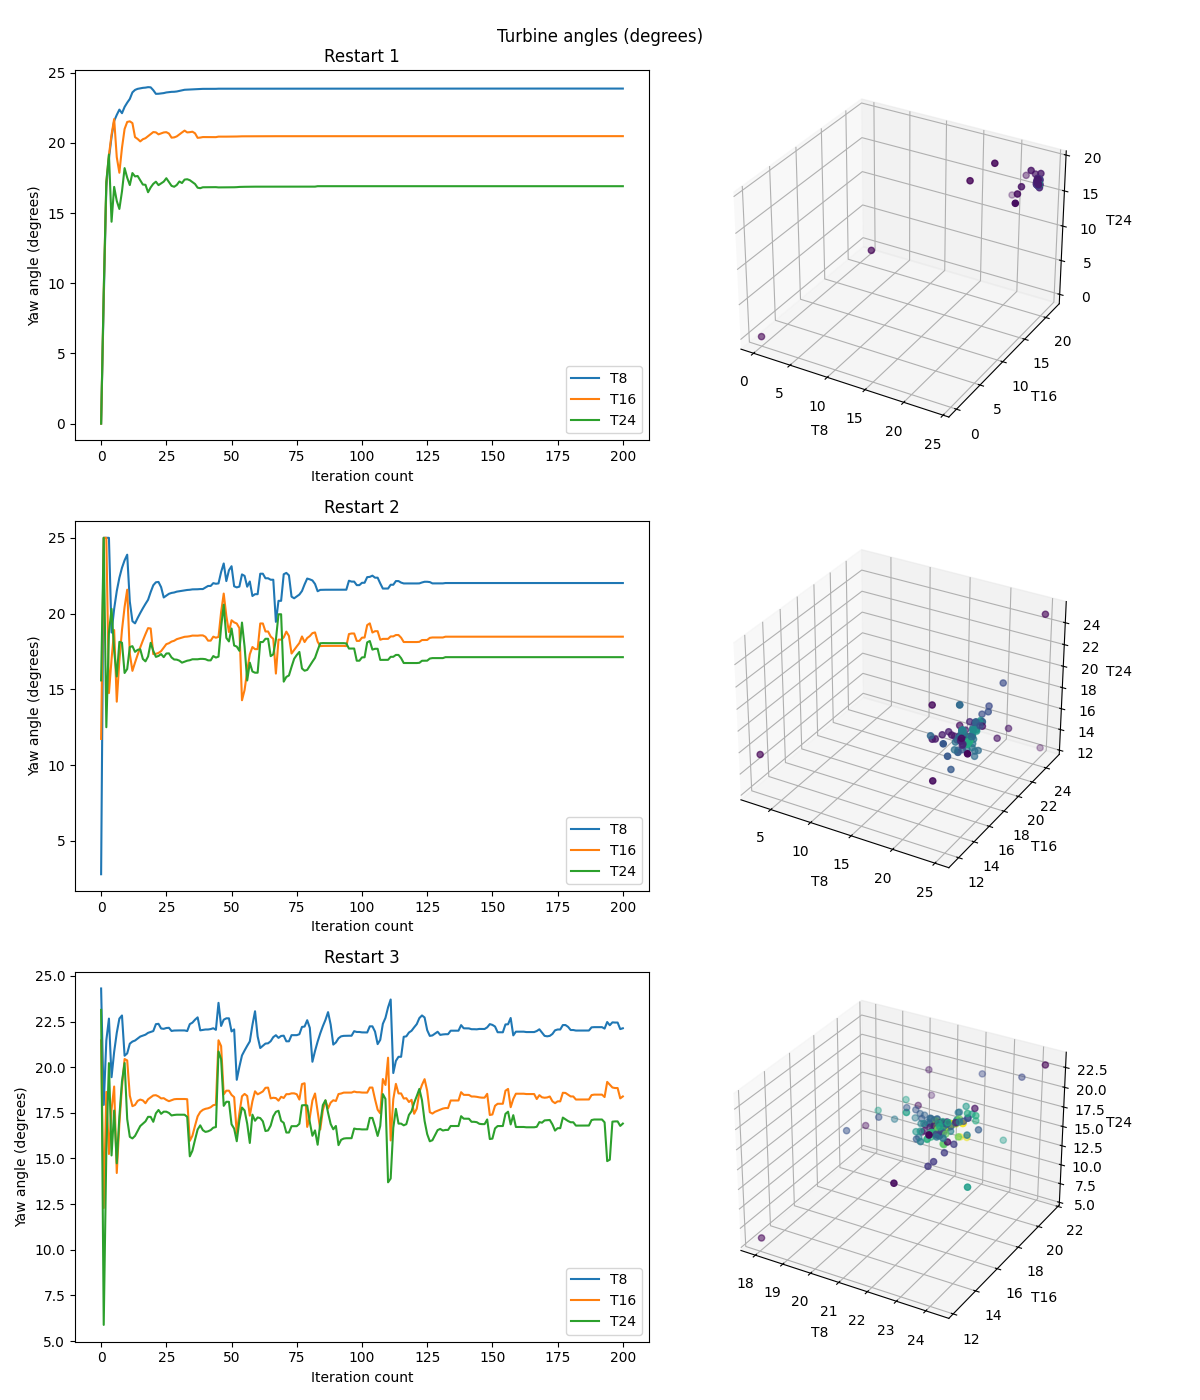

In [145]:
turbine_behaviour(t8, t16, t24)

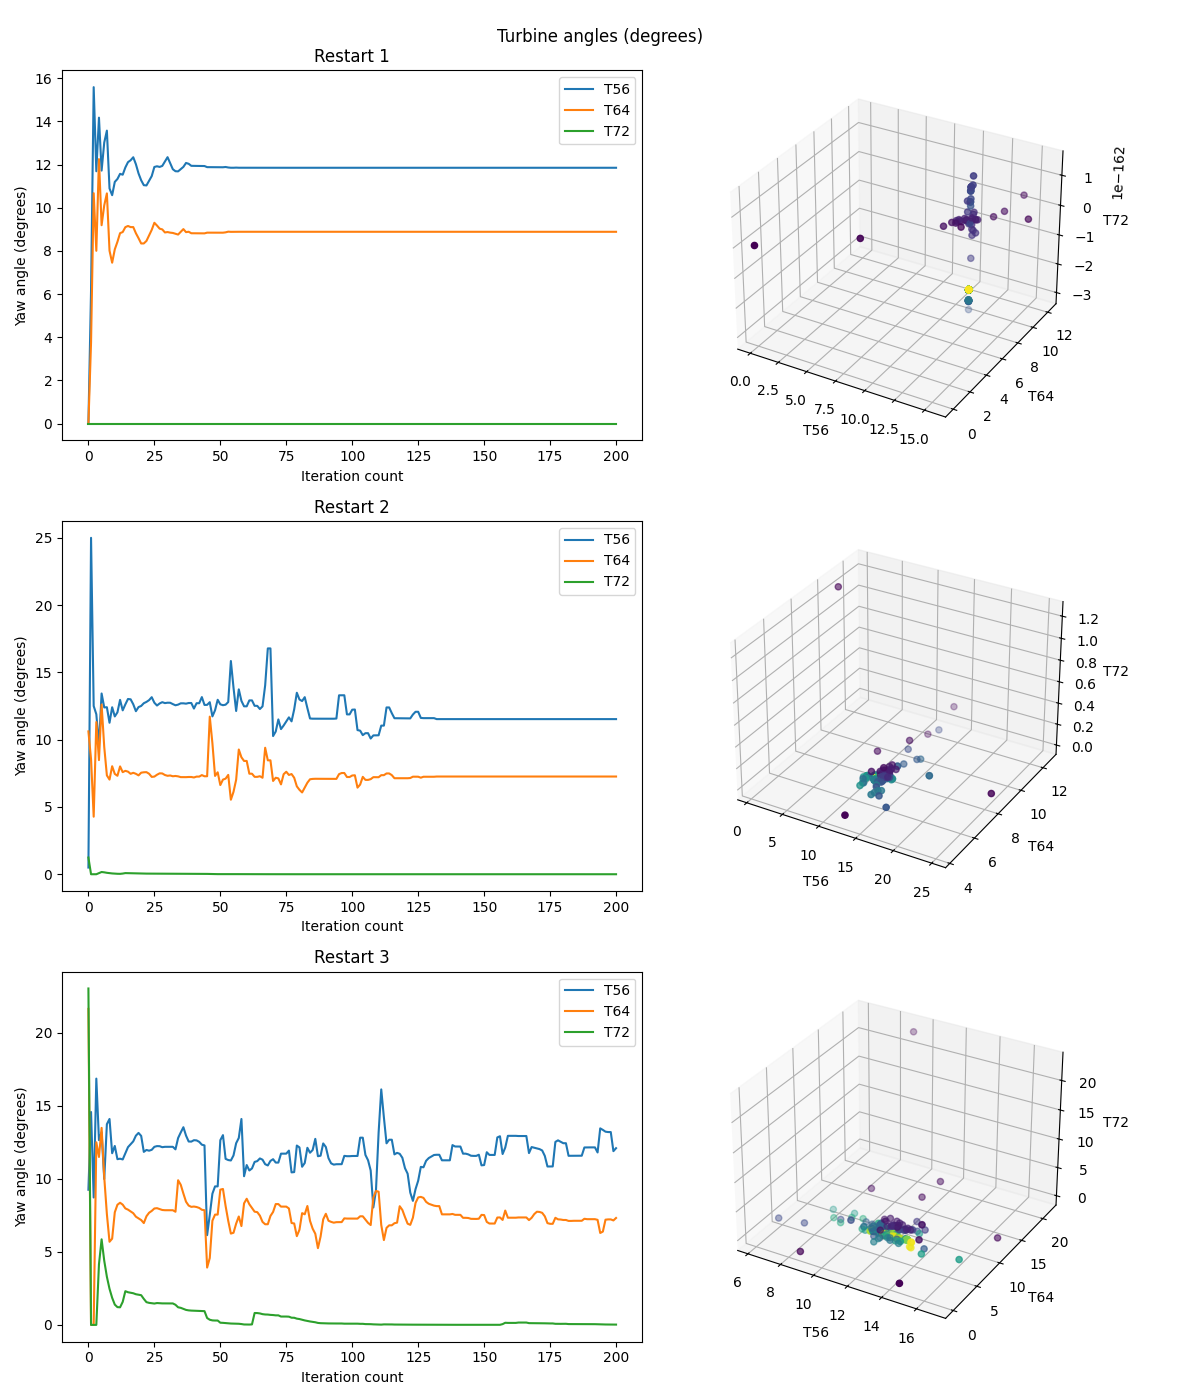

In [152]:
# A downstream row of 3~
t56, t64, t72 = 56, 64, 72
turbine_behaviour(t56, t64, t72)

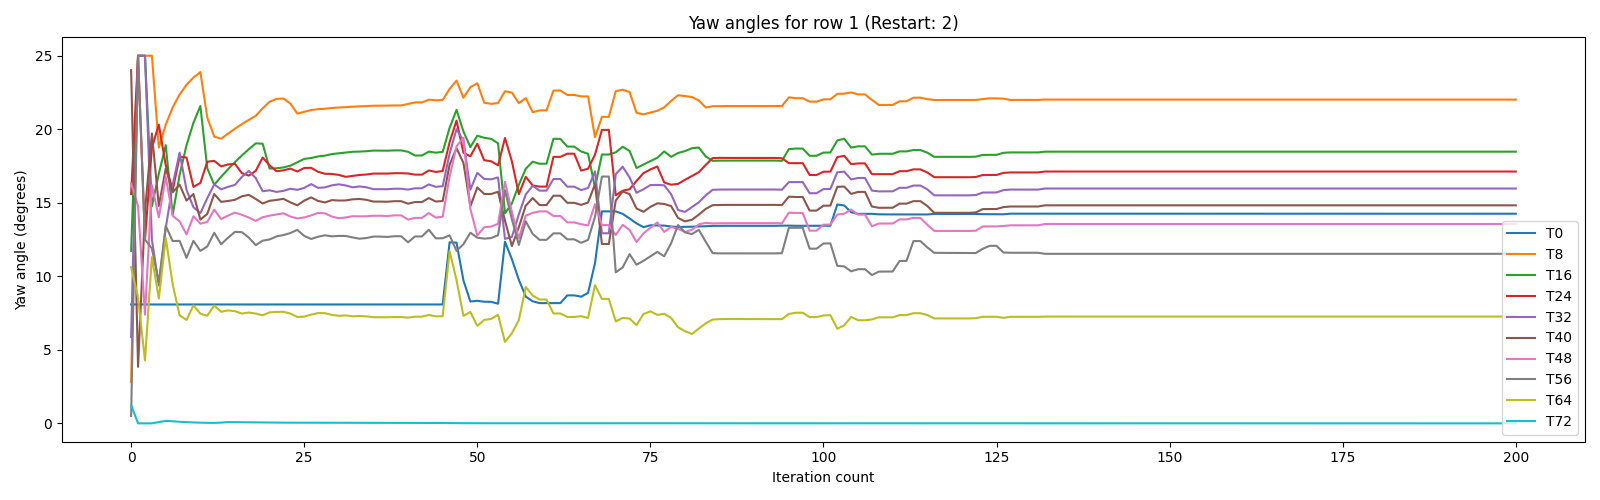

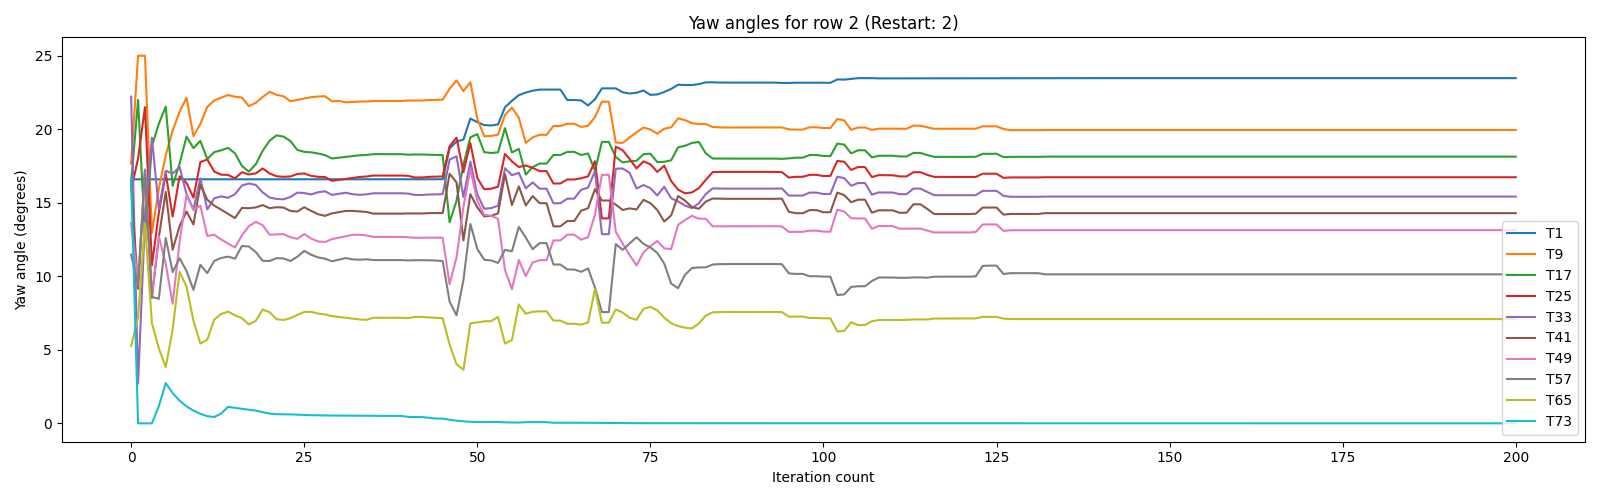

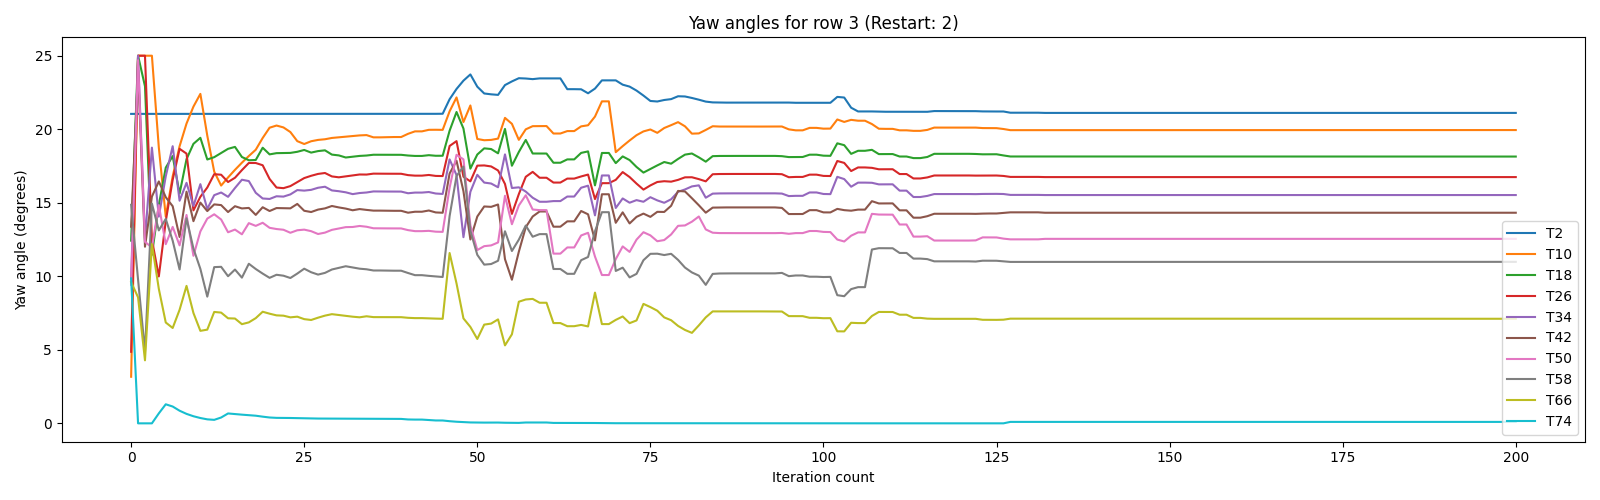

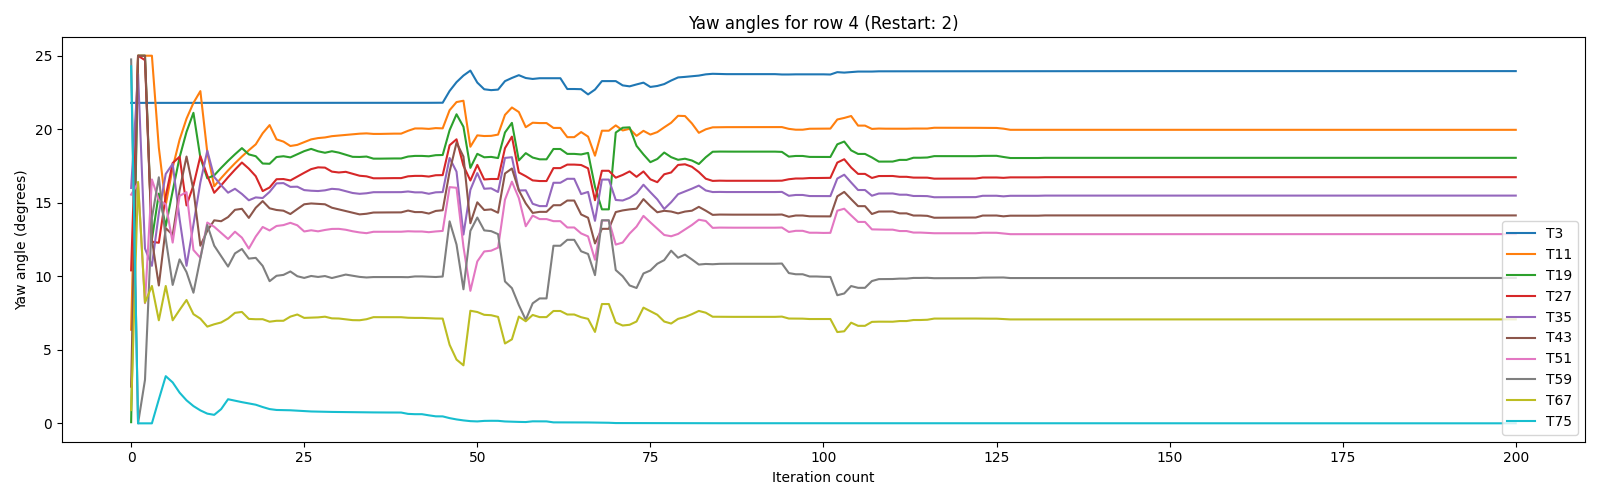

In [163]:
# Plot showing how yaw angles change for one entire row
def yaw_angle_per_row(row_number: int,
                      restart: int):
    if row_number == 0:
        raise ValueError("Please enter a valid row number (1-8)")

    match restart:
        case 3:
            start_idx, end_idx = 452, 656
        case 2:
            start_idx, end_idx = 251, 452
        case _:
            start_idx, end_idx = 50, 251


    plt.figure(figsize=(16, 5))
    # 10 turbines per row
    for i in range(10):
        plt.plot(slsqp_yaws[f"T{(row_number - 1) + (8 * i)}"][start_idx:end_idx], label=f"T{(row_number - 1) + (8 * i)}")

    plt.xlabel("Iteration count")
    plt.ylabel("Yaw angle (degrees)")
    plt.title(f"Yaw angles for row {row_number} (Restart: {restart})")
    plt.tight_layout()
    plt.legend()
    plt.show()

yaw_angle_per_row(1, 2)
yaw_angle_per_row(2, 2)
yaw_angle_per_row(3, 2)
yaw_angle_per_row(4, 2)

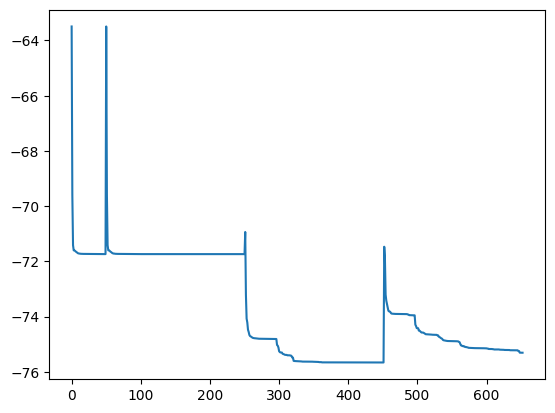

In [39]:

# Plot losses
# # Should have 600 iterations. Discard the first X for warmup
# slsqp_loss = np.array([slsqp_log[i]['loss'] for i in range(n_iters)])
# slsqp_r1 = slsqp_loss[50:251]
# slsqp_r2 = slsqp_loss[251:452]
# slsqp_r3 = slsqp_loss[452:656]


# plt.figure(figsize=(7, 6))
# plt.plot(slsqp_r1, label="Restart 1")
# plt.plot(slsqp_r2, label="Restart 2")
# plt.plot(slsqp_r3, label="Restart 3")
# plt.xlabel("Iteration no.")
# plt.ylabel("Loss (-MW)")
# plt.title("SLSQP (JAX) Convergence")
# plt.legend()
# plt.tight_layout()
# plt.show()